In [1]:
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
df = pd.read_csv('/content/drive/MyDrive/CTARidership.csv', parse_dates = ["service_date"])
df.columns = ["date", "day_type", "bus", "rail", "total"] #day_type: "W"=Weekday, "A"=Saturday and "U"=Sunday/New Year's Day/Memorial Day/Independence Day/Labor Day/Thanksgiving/Christmas Day
df = df.sort_values("date").set_index("date") #sort by date
df = df.drop("total", axis = 1) #drop total, it's just bus + rail
df = df.drop_duplicates() #for some reason, October 2011 and July 2014 are duplicated in the dataset
df

,day_type,bus,rail
date,,,
2001-01-01,U,297192,126455
2001-01-02,W,780827,501952
2001-01-03,W,824923,536432
2001-01-04,W,870021,550011
2001-01-05,W,890426,557917
...,...,...,...
2024-07-27,A,426551,328573
2024-07-28,U,305854,225835
2024-07-29,W,499487,347579


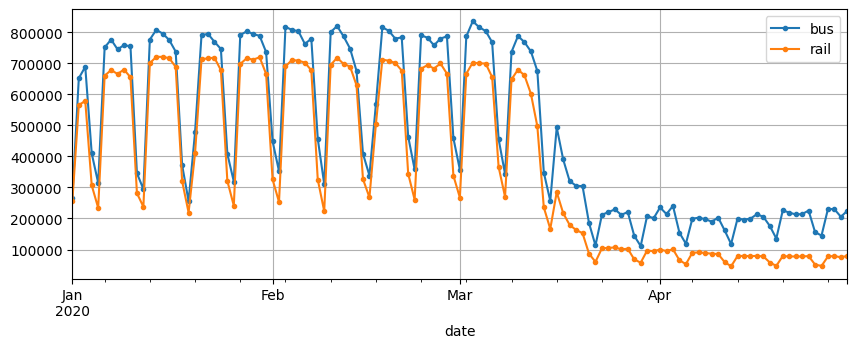

In [4]:
df["2020-01":"2020-04"].plot(grid = "True", marker = ".", figsize = (10,3.5))
plt.show()

**Naive forecasting**: There's a weekly seasonality effect, so just copy the values from the previous week

In [5]:
diff_7 = df[["rail"]].diff(7)["2019-03":"2019-06"]

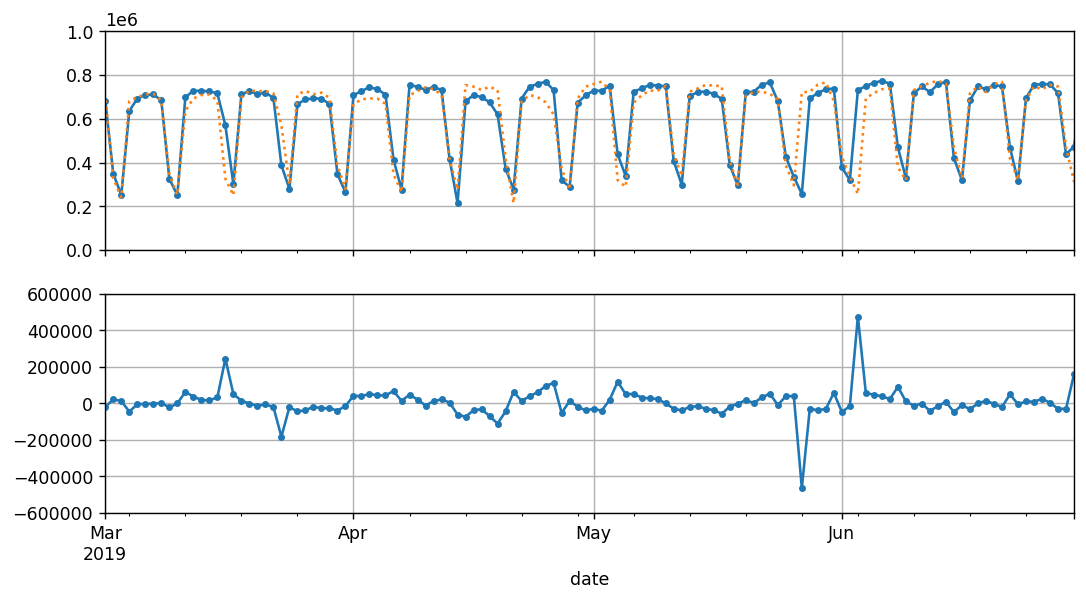

In [6]:
fig, axs = plt.subplots(2,1, sharex = True, figsize = (10,5), dpi = 125)
df["rail"].plot(ax = axs[0], legend = False, marker=".")
df["rail"].shift(7).plot(ax = axs[0], grid = True, legend = False, linestyle=":", ylim=(0, 1e6))
diff_7.plot(ax = axs[1], grid = True, legend = False, marker=".", ylim=(-6e5, 6e5))
plt.show()

It's pretty okay except for doing really badly on Memorial Day (end of May) - which leads to a bad estimate both on that day and a week later. Let's see how well it performs.

In [7]:
print(diff_7.abs().mean())

rail    42706.385246
dtype: float64


Number is MAE (mean absolute error), e.g. 43000 passengers off. (Compare with a few hundred thousand passengers a day).

**RNN**: Let's build an RNN instead!

In [8]:
df_rnn = df[["rail"]] / 1e6
df_rnn["next_day_type"] = df["day_type"].shift(-1)
df_rnn = pd.get_dummies(df_rnn) #one-hot encode next day type
df_rnn.head()

,rail,next_day_type_A,next_day_type_U,next_day_type_W
date,,,,
2001-01-01,0.126455,False,False,True
2001-01-02,0.501952,False,False,True
2001-01-03,0.536432,False,False,True
2001-01-04,0.550011,False,False,True
2001-01-05,0.557917,True,False,False


In [9]:
train_set = df_rnn["2015-01":"2018-09"]
valid_set = df_rnn["2018-10":"2019-02"]
test_set = df_rnn["2019-03":"2019-06"]

In [10]:
seq_length = 56
train_ds = tf.keras.utils.timeseries_dataset_from_array(
    np.asarray(train_set).astype('float32'),
    targets = train_set[["rail"]][seq_length:],
    sequence_length = seq_length,
    batch_size = 32,
    shuffle = True,
    seed = 42
)

valid_ds = tf.keras.utils.timeseries_dataset_from_array(
    np.asarray(valid_set).astype('float32'),
    targets = valid_set[["rail"]][seq_length:],
    sequence_length = seq_length,
    batch_size = 32
)

test_ds = tf.keras.utils.timeseries_dataset_from_array(
    np.asarray(test_set).astype('float32'),
    targets = test_set[["rail"]][seq_length:],
    sequence_length = seq_length,
    batch_size = 32
)

In [11]:
rnn_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=[None, 4]), #None = sequence length, we accept any size, 4 = four outputs (3 day types, #passengers)
    tf.keras.layers.SimpleRNN(32),
    tf.keras.layers.Dense(1) #to boil everything down to 1 unbound number: rail passengers
])

early_stopping_cb = tf.keras.callbacks.EarlyStopping(monitor = "val_mae", patience = 50, restore_best_weights=True)
optimizer = tf.keras.optimizers.SGD(learning_rate = 0.02, momentum = 0.9)
rnn_model.compile(loss=tf.keras.losses.Huber(), optimizer = optimizer, metrics = ["mae"])
history = rnn_model.fit(train_ds, validation_data = valid_ds, epochs = 500, callbacks = [early_stopping_cb])

Epoch 1/500
42/42 ━━━━━━━━━━━━━━━━━━━━ 4s 37ms/step - loss: 0.0364 - mae: 0.1782 - val_loss: 0.0113 - val_mae: 0.1083
Epoch 2/500
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0023 - mae: 0.0486 - val_loss: 0.0063 - val_mae: 0.0648
Epoch 3/500
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0022 - mae: 0.0506 - val_loss: 0.0095 - val_mae: 0.0949
Epoch 4/500
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0020 - mae: 0.0414 - val_loss: 0.0070 - val_mae: 0.0715
Epoch 5/500
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0015 - mae: 0.0367 - val_loss: 0.0082 - val_mae: 0.0858
Epoch 6/500
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0017 - mae: 0.0416 - val_loss: 0.0063 - val_mae: 0.0660
Epoch 7/500
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0016 - mae: 0.0382 - val_loss: 0.0077 - val_mae: 0.0815
Epoch 8/500
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0013 - mae: 0.0350 - val_loss: 0.0057 - val_mae: 0.0620
Epoch 9/500
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.00

In [12]:
test_set_with_prev_56_days = df_rnn["2019-01-04":"2019-06"]
X = np.asarray(test_set_with_prev_56_days).astype('float32')[np.newaxis]

In [14]:
date_range = pd.date_range(start = "2019-03-01", end = "2019-06-30")
y = []
for step in range(31+30+31+30):
    y_pred_number = rnn_model.predict(X[:,step:seq_length + step], verbose = False)
    y.append(*y_pred_number)

y = [element*1e6 for innerList in y for element in innerList]
Y_pred = pd.Series(data = y, index = date_range)

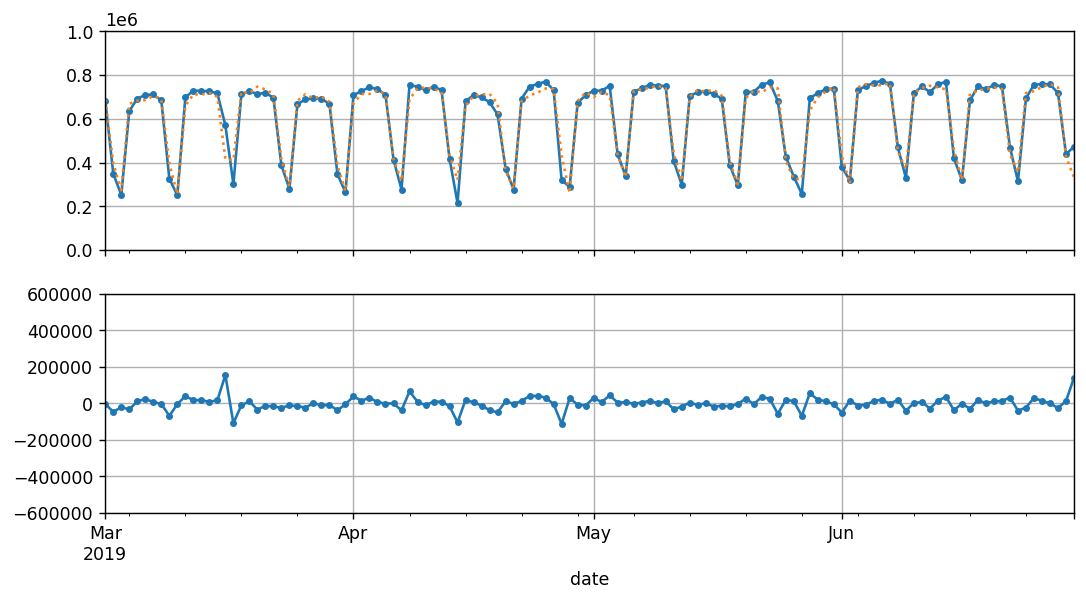

In [15]:
diff = df["rail"]["2019-03":"2019-06"] - Y_pred

fig, axs = plt.subplots(2,1, sharex = True, figsize = (10,5), dpi = 125)
df["rail"]["2019-03":"2019-06"].plot(ax = axs[0], legend = False, marker=".")
Y_pred.plot(ax = axs[0], grid = True, legend = False, linestyle=":", ylim=(0, 1e6))
diff.plot(ax = axs[1], grid = True, marker=".", ylim=(-6e5, 6e5))
plt.show()

In [16]:
print(diff.abs().mean())

23500.759861680326


Note that here, we are using the actual data from the previous 56 days to predict tomorrow. To make a longer forecast, we could either
* append the predicted y to X every day and use that for our next prediction (which will make the forecast worse and worse as we go further away from the true data - this is called autoregression).
* train a new model to forecast, let's say, 14 days instead of just the next day. Then the output layer in our model should simply have 14 output neurons instead of one.
* ... several other approaches - RNNs are versatile!